# Score vs ABSA sentiment metrics

Этот ноутбук оценивает связь итоговой оценки рецензии (`score`) с агрегатами по ABSA:
- `neg_share`
- `pos_share`

In [9]:
from __future__ import annotations

import json
import math
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import pearsonr, spearmanr

plt.style.use("seaborn-v0_8-whitegrid")

In [10]:
# Укажите путь к результату gigachat_absa_reviews.py
ABSA_JSONL_PATH = Path("output_gigachatPRO_absa_preprocessed_v3.jsonl")

if not ABSA_JSONL_PATH.exists():
    raise FileNotFoundError(f"File not found: {ABSA_JSONL_PATH}")

In [11]:
def parse_score(value: Any) -> float | None:
    """Parse score from int/float/string; return None if invalid."""
    if value is None:
        return None
    if isinstance(value, bool):
        return None
    if isinstance(value, (int, float)):
        if isinstance(value, float) and math.isnan(value):
            return None
        return float(value)

    text = str(value).strip().replace(",", ".")
    if not text:
        return None

    try:
        return float(text)
    except ValueError:
        return None


def parse_rating_fallback(value: Any, agg: str = "mean") -> float | None:
    """Fallback parser for `rating`:
    - scalar -> parse directly
    - dict -> aggregate parsed non-empty values by agg: mean|median|mode
    """
    if isinstance(value, dict):
        parsed_vals: list[float] = []
        for item in value.values():
            parsed = parse_score(item)
            if parsed is not None:
                parsed_vals.append(parsed)
        if not parsed_vals:
            return None

        agg_norm = agg.lower().strip()
        if agg_norm == "mean":
            return sum(parsed_vals) / len(parsed_vals)
        if agg_norm == "median":
            sorted_vals = sorted(parsed_vals)
            n = len(sorted_vals)
            mid = n // 2
            if n % 2 == 1:
                return sorted_vals[mid]
            return (sorted_vals[mid - 1] + sorted_vals[mid]) / 2
        if agg_norm == "mode":
            counts: dict[float, int] = {}
            for v in parsed_vals:
                counts[v] = counts.get(v, 0) + 1
            max_count = max(counts.values())
            modes = [v for v, c in counts.items() if c == max_count]
            return min(modes)

        raise ValueError("Unsupported agg. Use one of: mean, median, mode")

    return parse_score(value)


def compute_absa_metrics(items: Any) -> dict[str, float | int]:
    if not isinstance(items, list):
        return {
            "n_pos": 0,
            "n_neg": 0,
            "n_total": 0,
            "pos_share": float("nan"),
            "neg_share": float("nan"),
            "sentiment_index": float("nan"),
        }

    n_pos = 0
    n_neg = 0
    for item in items:
        if not isinstance(item, dict):
            continue
        pol = str(item.get("polarity", "")).strip().upper()
        if pol == "POS":
            n_pos += 1
        elif pol == "NEG":
            n_neg += 1

    n_total = n_pos + n_neg
    if n_total == 0:
        return {
            "n_pos": n_pos,
            "n_neg": n_neg,
            "n_total": n_total,
            "pos_share": float("nan"),
            "neg_share": float("nan"),
            "sentiment_index": float("nan"),
        }

    pos_share = n_pos / n_total
    neg_share = n_neg / n_total
    sentiment_index = (n_pos - n_neg) / n_total

    return {
        "n_pos": n_pos,
        "n_neg": n_neg,
        "n_total": n_total,
        "pos_share": pos_share,
        "neg_share": neg_share,
        "sentiment_index": sentiment_index,
    }

In [12]:
with ABSA_JSONL_PATH.open("r", encoding="utf-8") as f:
    ALL_RECORDS = [json.loads(line) for line in f if line.strip()]


def build_df(score_mode: str = "mean") -> pd.DataFrame:
    """score_mode: one of none|mean|median|mode"""
    mode = score_mode.lower().strip()
    if mode not in {"none", "mean", "median", "mode"}:
        raise ValueError("Unsupported score_mode. Use one of: none, mean, median, mode")

    rows: list[dict[str, Any]] = []
    for rec in ALL_RECORDS:
        score = parse_score(rec.get("rating_overall"))

        if mode == "none":
            # Без агрегации: берём только rating_overall, записи без него отбрасываем.
            if score is None:
                continue
        else:
            # С агрегацией: fallback на rating_details,
            # если rating_overall отсутствует или выглядит как суммарный балл (>10).
            if score is None or score > 10:
                score = parse_rating_fallback(rec.get("rating_details"), agg=mode)
            if score is None:
                continue

        metrics = compute_absa_metrics(rec.get("absa_items"))
        rows.append(
            {
                "year": rec.get("year"),
                "reviewer_id": rec.get("reviewer_id", rec.get("reviewer")),
                "book_title": rec.get("book_title"),
                "book_author": rec.get("book_author"),
                "score": score,
                **metrics,
            }
        )

    return pd.DataFrame(rows)


# Базовый датафрейм для последующих ячеек/графиков.
df = build_df("mean")
print(f"Rows with valid score (mean fallback): {len(df)}")
print(f"Rows with non-empty ABSA tuples: {(df['n_total'] > 0).sum() if len(df) else 0}")
df.head()

Rows with valid score (mean fallback): 163
Rows with non-empty ABSA tuples: 145


,year,reviewer_id,book_title,book_author,score,n_pos,n_neg,n_total,pos_share,neg_share,sentiment_index
0,2024,R13,Русская ловушка,None,9.375000,4,0,4,1.0,0.0,1.0
1,2023,R16,Почему важна демография,None,5.333333,0,4,4,0.0,1.0,-1.0
2,2024,R13,Перманентная современность и динамика культуры,None,7.375000,2,3,5,0.4,0.6,-0.2
3,2024,R14,Урбанизация по-китайски,None,8.000000,3,0,3,1.0,0.0,1.0
4,2023,R5,Имидж региона в стратегии развития территории,None,5.000000,3,7,10,0.3,0.7,-0.4


In [13]:
df = df.query('(score <= 10) & (score > 0)').reset_index(drop=True)

In [14]:
metrics = ["neg_share", "pos_share"]
score_modes = ["none", "mean", "median", "mode"]

corr_rows: list[dict[str, Any]] = []
for mode in score_modes:
    df_mode = build_df(mode)
    df_mode = df_mode.query("score <= 10").reset_index(drop=True)

    for metric in metrics:
        tmp = df_mode[["score", metric]].dropna()
        n = len(tmp)
        if n < 3:
            corr_rows.append(
                {
                    "score_mode": mode,
                    "metric": metric,
                    "n": n,
                    "spearman_r": float("nan"),
                    "spearman_p": float("nan"),
                    "pearson_r": float("nan"),
                    "pearson_p": float("nan"),
                    "note": "Not enough data (<3 rows with non-NaN metric)",
                }
            )
            continue

        sp_r, sp_p = spearmanr(tmp["score"], tmp[metric])
        pr_r, pr_p = pearsonr(tmp["score"], tmp[metric])
        corr_rows.append(
            {
                "score_mode": mode,
                "metric": metric,
                "n": n,
                "spearman_r": sp_r,
                "spearman_p": sp_p,
                "pearson_r": pr_r,
                "pearson_p": pr_p,
                "note": "",
            }
        )

corr_df = pd.DataFrame(corr_rows)
corr_df

,score_mode,metric,n,spearman_r,spearman_p,pearson_r,pearson_p,note
0,none,neg_share,112,-0.650533,8.289461e-15,-0.641272,2.599108e-14,
1,none,pos_share,112,0.650533,8.289461e-15,0.641272,2.599108e-14,
2,mean,neg_share,145,-0.533930,4.657561e-12,-0.528042,8.773630e-12,
3,mean,pos_share,145,0.533930,4.657561e-12,0.528042,8.773630e-12,
4,median,neg_share,145,-0.515895,3.119528e-11,-0.508767,6.416878e-11,
5,median,pos_share,145,0.515895,3.119528e-11,0.508767,6.416878e-11,
6,mode,neg_share,145,-0.502093,1.242142e-10,-0.416448,1.888954e-07,
7,mode,pos_share,145,0.502093,1.242142e-10,0.416448,1.888954e-07,


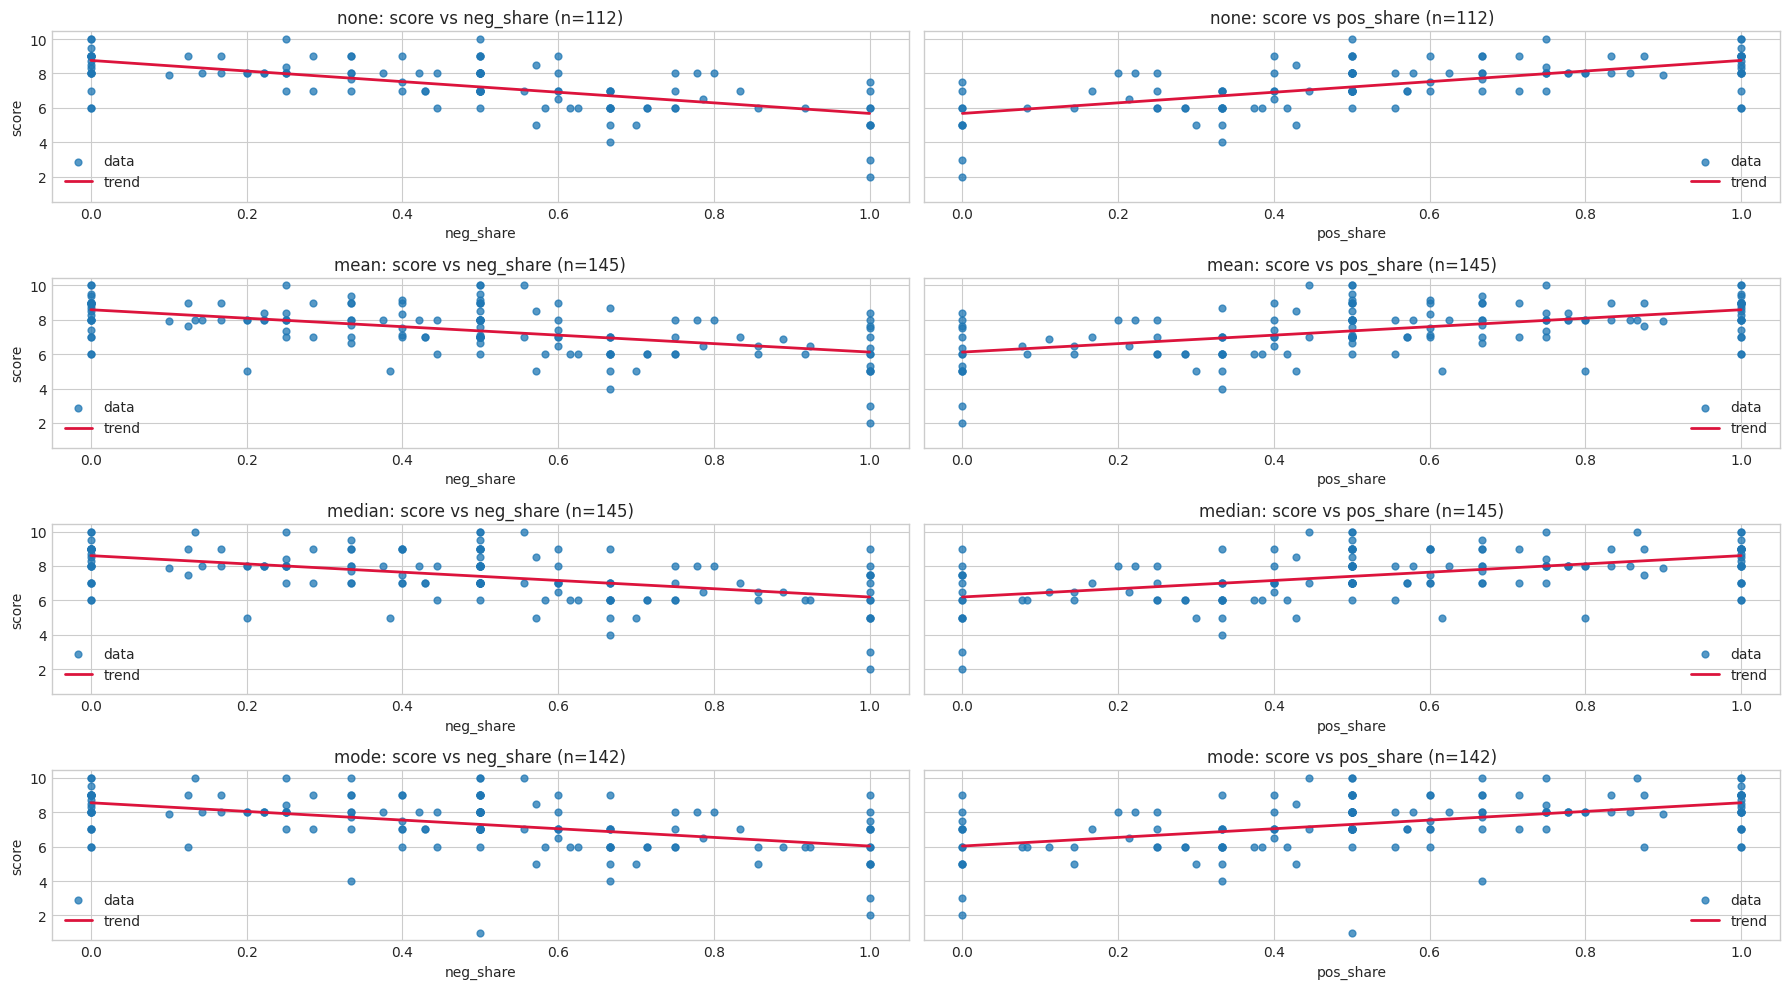

In [15]:
import numpy as np

# Визуализация для всех режимов score_mode: none / mean / median / mode
fig, axes = plt.subplots(len(score_modes), len(metrics), figsize=(18, 10), sharey=True)

for row_idx, mode in enumerate(score_modes):
    df_mode = build_df(mode).query("(score <= 10) & (score > 0)").reset_index(drop=True)

    for col_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        tmp = df_mode[["score", metric]].dropna()
        ax.scatter(tmp[metric], tmp["score"], alpha=0.75, s=24, label="data")

        if len(tmp) >= 2:
            x = tmp[metric].to_numpy()
            y = tmp["score"].to_numpy()
            slope, intercept = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 100)
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, color="crimson", linewidth=2, label="trend")

        ax.set_xlabel(metric)
        ax.set_title(f"{mode}: score vs {metric} (n={len(tmp)})")
        ax.legend(loc="best")

        if col_idx == 0:
            ax.set_ylabel("score")

plt.tight_layout()
plt.show()

In [16]:
# Опционально: сохранить агрегированную таблицу
OUT_CSV = ABSA_JSONL_PATH.with_name("absa_score_metrics.csv")
df.to_csv(OUT_CSV, index=False)
OUT_CSV

PosixPath('absa_score_metrics.csv')